# Sigap.ai - Logistic Regression Baseline for Sentiment Analysis

Notebook ini disusun untuk proyek capstone IBM SkillsBuild Sigap.ai sebagai baseline yang dapat langsung dijalankan di Google Colab.

Scope notebook ini dibatasi secara tegas pada data yang sudah final:
- proses data collection sudah selesai
- proses cleaning sudah selesai
- proses labeling sudah selesai
- proses balancing sudah selesai
- proses splitting sudah selesai
- proses preprocessing sudah selesai

Eksperimen ini hanya menggunakan:
- feature: `Review_Text_Processed`
- target: `Sentiment_Label`

Notebook mencakup:
- loading data train/validation/test
- label encoding
- TF-IDF feature engineering
- baseline Logistic Regression
- hyperparameter tuning
- final model training
- evaluasi validation dan test
- visualisasi profesional
- error analysis
- explainable AI
- business analysis
- penyimpanan model dan ekspor hasil

## SECTION 1 - Project Overview

### Tujuan eksperimen
Tujuan eksperimen ini adalah membangun baseline klasifikasi sentimen yang kuat, interpretabel, dan mudah direplikasi untuk dataset review UMKM Indonesia pada proyek Sigap.ai. Fokus utama notebook ini bukan membangun model paling kompleks, tetapi menghasilkan benchmark yang kredibel untuk membandingkan metode lanjutan pada eksperimen berikutnya.

### Alasan menggunakan Logistic Regression sebagai baseline
Logistic Regression merupakan baseline yang tepat untuk problem klasifikasi teks dengan TF-IDF karena:
- bekerja sangat baik pada data sparse berdimensi tinggi
- cepat dilatih dan cepat dievaluasi
- stabil untuk multi-class classification
- mudah diinterpretasikan melalui koefisien fitur
- menjadi pembanding yang solid sebelum mencoba model neural network atau transformer

Dalam konteks capstone, baseline ini juga penting untuk menunjukkan bahwa performa model berasal dari proses yang terukur, bukan dari kompleksitas model semata.

## SECTION 2 - Import Library

Library yang digunakan dibatasi pada stack yang umum dipakai untuk eksperimen machine learning terstruktur:
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

In [28]:
import os
from pathlib import Path

import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, validation_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11
pd.set_option('display.max_colwidth', 250)
pd.set_option('display.max_columns', 100)

## SECTION 3 - Load Dataset

Notebook ini mencoba menemukan file dataset secara otomatis agar tetap fleksibel saat dijalankan di Google Colab maupun pada workspace lokal.

Jika nama file Anda adalah `df_train_final.csv`, `df_validation_final.csv`, dan `df_test_final.csv`, notebook akan tetap mencarinya. Jika file yang tersedia adalah `train_final.csv`, `validation_final.csv`, dan `test_final.csv`, notebook juga akan menggunakannya.

In [29]:
PROJECT_ROOT = Path.cwd()

TRAIN_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "train.csv"
VAL_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "validation.csv"
TEST_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "test.csv"

print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)

print("\nDataset Loaded Successfully")
print("Train      :", df_train.shape)
print("Validation :", df_val.shape)
print("Test       :", df_test.shape)

print("\nColumns:")
print(df_train.columns.tolist())

c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\train.csv
c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\validation.csv
c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\test.csv

Dataset Loaded Successfully
Train      : (37391, 9)
Validation : (8025, 9)
Test       : (8024, 9)

Columns:
['Review_Text', 'Review_Text_Processed', 'Review_Date', 'Rating_Score', 'Business_Category', 'Sentiment_Label', 'Review_Aspect', 'Crisis_Flag', 'Is_Sarcasm']


In [30]:
expected_columns = [
    'Review_Text',
    'Review_Text_Processed',
    'Review_Date',
    'Rating_Score',
    'Business_Category',
    'Sentiment_Label',
    'Review_Aspect',
    'Crisis_Flag',
    'Is_Sarcasm'
]

for split_name, df in [
    ('Train', df_train),
    ('Validation', df_val),
    ('Test', df_test)
]:
    missing = [c for c in expected_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f'{split_name} missing columns: {missing}'
        )

    print(f'\n{split_name} shape: {df.shape}')
    print('Label distribution:')
    display(df['Sentiment_Label'].value_counts().to_frame('count'))

    print('Sample data:')
    display(
        df[
            ['Review_Text_Processed', 'Sentiment_Label']
        ].head(5)
    )

train_df = df_train.copy()
val_df = df_val.copy()
test_df = df_test.copy()

print("\nDataset validation passed")


Train shape: (37391, 9)
Label distribution:


,count
Sentiment_Label,
Negative,12499
Netral,12493
Positive,12399


Sample data:


,Review_Text_Processed,Sentiment_Label
0,terimakasih packing aman bagus,Positive
1,aplikasi bikin ribet pesan skor performa aneh apliksi,Netral
2,draftanakunpad3 cobain fore matchanya asa sen less sugar wktu pas tidak banyak susu cream,Netral
3,yummyyy cocok ngemil abis tarawih alhamdulillah harga lumayan obat kangen,Netral
4,with nice ambiance and sushi it may be called mahal but unfortunately the is not jangkau,Positive



Validation shape: (8025, 9)
Label distribution:


...


Test shape: (8024, 9)
Label distribution:


,count
Sentiment_Label,
Negative,2680
Netral,2674
Positive,2670


Sample data:


,Review_Text_Processed,Sentiment_Label
0,this store maintains the kualitas brand name of domino their burger pizza is great in its perfect balance of spices the bland bread our was delivered on time and in good condition overall its alam,Positive
1,order gacor sengdangkan kouta ttp,Netral
2,giving coz had to take different cake not the one which chose,Positive
3,parah go gek masak order go food diemin hari saldo blum rekening ulang komplain admin msih lambat masuk saldo rekening uang hasil jual pakai modal bahan baku masakan resto evaluasi kerja sistem kerja adminya go food terima kasih,Negative
4,hi got cake from here which called some joy cake chocolate very good and delicioasa superb would recommend to anyone will try it again and again,Positive



Dataset validation passed


## SECTION 4 - Label Encoding

Target label pada dataset menggunakan istilah `Netral`, sedangkan eksperimen ini menggunakan standar akademik yang lebih konsisten, yaitu `Neutral`.

Pada tahap ini:
- label distandarkan menjadi `Positive`, `Neutral`, `Negative`
- label kemudian diencode menggunakan `LabelEncoder`
- mapping label disimpan agar interpretasi hasil tetap transparan

In [31]:
def standardize_label(label):
    label = str(label).strip()
    if label.lower() == 'netral':
        return 'Neutral'
    return label

for df in [train_df, val_df, test_df]:
    df['Sentiment_Label'] = df['Sentiment_Label'].apply(standardize_label)

label_order = ['Negative', 'Neutral', 'Positive']
label_encoder = LabelEncoder()
label_encoder.fit(label_order)

label_mapping = {label: int(label_encoder.transform([label])[0]) for label in label_encoder.classes_}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}

print('Label Mapping:')
display(pd.DataFrame({'label': list(label_mapping.keys()), 'encoded_value': list(label_mapping.values())}))

train_y = label_encoder.transform(train_df['Sentiment_Label'])
val_y = label_encoder.transform(val_df['Sentiment_Label'])
test_y = label_encoder.transform(test_df['Sentiment_Label'])

print('Encoded classes:', list(label_encoder.classes_))

Label Mapping:


,label,encoded_value
0,Negative,0
1,Neutral,1
2,Positive,2


Encoded classes: [np.str_('Negative'), np.str_('Neutral'), np.str_('Positive')]


## SECTION 5 - TF-IDF Feature Engineering

Eksperimen TF-IDF dilakukan untuk membandingkan representasi teks yang berbeda sebelum model final dibangun.

Konfigurasi yang diuji:
1. Unigram
2. Unigram + Bigram
3. Tuning `max_features`

Semua eksperimen pada section ini memakai Logistic Regression default sebagai pembanding, lalu dievaluasi pada validation set.

In [32]:
# ============================================================
# TEXT PREPARATION
# ============================================================

X_train = (
    train_df["Review_Text_Processed"]
    .fillna("")
    .astype(str)
)

X_val = (
    val_df["Review_Text_Processed"]
    .fillna("")
    .astype(str)
)

X_test = (
    test_df["Review_Text_Processed"]
    .fillna("")
    .astype(str)
)

# ============================================================
# PIPELINE
# ============================================================

def build_pipeline(tfidf_params, lr_params=None):

    if lr_params is None:
        lr_params = {}

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True,
        norm="l2",
        smooth_idf=True,
        use_idf=True,
        **tfidf_params
    )

    classifier = LogisticRegression(
        random_state=42,
        max_iter=5000,
        C=5,
        class_weight="balanced",
        n_jobs=-1,
        **lr_params
    )

    return Pipeline([
        ("tfidf", vectorizer),
        ("logreg", classifier)
    ])

# ============================================================
# EVALUATION
# ============================================================

def evaluate_pipeline(
    pipeline,
    x_train,
    y_train,
    x_eval,
    y_eval
):

    pipeline.fit(x_train, y_train)

    pred = pipeline.predict(x_eval)
    proba = pipeline.predict_proba(x_eval)

    return {
        "accuracy": accuracy_score(y_eval, pred),
        "precision_macro": precision_score(
            y_eval,
            pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_eval,
            pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_eval,
            pred,
            average="macro",
            zero_division=0
        ),
        "pred": pred,
        "proba": proba,
        "pipeline": pipeline
    }

# ============================================================
# EXPERIMENT 1
# WORD VS CHARACTER TF-IDF
# ============================================================

experiment_rows = []

ngram_experiments = [

    (
        "Word Unigram",
        {
            "analyzer": "word",
            "ngram_range": (1, 1),
            "max_features": 50000,
            "min_df": 2,
            "max_df": 0.95
        }
    ),

    (
        "Word Unigram + Bigram",
        {
            "analyzer": "word",
            "ngram_range": (1, 2),
            "max_features": 50000,
            "min_df": 2,
            "max_df": 0.95
        }
    ),

    (
        "Word Unigram + Bigram + Trigram",
        {
            "analyzer": "word",
            "ngram_range": (1, 3),
            "max_features": 50000,
            "min_df": 2,
            "max_df": 0.95
        }
    ),

    (
        "Character 3-5",
        {
            "analyzer": "char_wb",
            "ngram_range": (3, 5),
            "max_features": 100000,
            "min_df": 2
        }
    )
]

for exp_name, tfidf_params in ngram_experiments:

    pipeline = build_pipeline(tfidf_params)

    result = evaluate_pipeline(
        pipeline,
        X_train,
        train_y,
        X_val,
        val_y
    )

    experiment_rows.append({
        "experiment": exp_name,
        "accuracy": result["accuracy"],
        "precision_macro": result["precision_macro"],
        "recall_macro": result["recall_macro"],
        "f1_macro": result["f1_macro"],
        "vocab_size": len(
            result["pipeline"]
            .named_steps["tfidf"]
            .vocabulary_
        ),
        "params": str(tfidf_params)
    })

experiment_results = pd.DataFrame(experiment_rows)

display(
    experiment_results.sort_values(
        "f1_macro",
        ascending=False
    )
)

# ============================================================
# BEST CONFIG
# ============================================================

best_row = (
    experiment_results
    .sort_values(
        "f1_macro",
        ascending=False
    )
    .iloc[0]
)

BEST_TFIDF_PARAMS = eval(
    best_row["params"]
)

print("\nBest TF-IDF Configuration")
print(BEST_TFIDF_PARAMS)

print("\nBest Validation F1")
print(round(best_row["f1_macro"], 4))

# ============================================================
# EXPERIMENT 2
# MAX FEATURES + MIN_DF
# ============================================================

experiment_rows = []

max_features_grid = [
    30000,
    50000,
    70000,
    100000
]

min_df_grid = [
    2,
    3,
    5
]

for mf in max_features_grid:

    for min_df in min_df_grid:

        tfidf_params = BEST_TFIDF_PARAMS.copy()

        tfidf_params["max_features"] = mf
        tfidf_params["min_df"] = min_df

        pipeline = build_pipeline(tfidf_params)

        result = evaluate_pipeline(
            pipeline,
            X_train,
            train_y,
            X_val,
            val_y
        )

        experiment_rows.append({
            "experiment": f"mf={mf}_min_df={min_df}",
            "max_features": mf,
            "min_df": min_df,
            "accuracy": result["accuracy"],
            "precision_macro": result["precision_macro"],
            "recall_macro": result["recall_macro"],
            "f1_macro": result["f1_macro"],
            "vocab_size": len(
                result["pipeline"]
                .named_steps["tfidf"]
                .vocabulary_
            )
        })

experiment_results = (
    pd.DataFrame(experiment_rows)
    .sort_values(
        "f1_macro",
        ascending=False
    )
    .reset_index(drop=True)
)

display(experiment_results)

best_row = experiment_results.iloc[0]

BEST_TFIDF_PARAMS["max_features"] = int(
    best_row["max_features"]
)

BEST_TFIDF_PARAMS["min_df"] = int(
    best_row["min_df"]
)

print("\nFinal Best TF-IDF Configuration")
print(BEST_TFIDF_PARAMS)

print("\nBest Validation F1")
print(round(best_row["f1_macro"], 4))

,experiment,accuracy,precision_macro,recall_macro,f1_macro,vocab_size,params
1,Word Unigram + Bigram,0.749159,0.747034,0.749348,0.747912,50000,"{'analyzer': 'word', 'ngram_range': (1, 2), 'max_features': 50000, 'min_df': 2, 'max_df': 0.95}"
2,Word Unigram + Bigram + Trigram,0.746044,0.744010,0.746234,0.744896,50000,"{'analyzer': 'word', 'ngram_range': (1, 3), 'max_features': 50000, 'min_df': 2, 'max_df': 0.95}"
3,Character 3-5,0.735078,0.733363,0.735273,0.734100,73460,"{'analyzer': 'char_wb', 'ngram_range': (3, 5), 'max_features': 100000, 'min_df': 2}"
0,Word Unigram,0.732960,0.730874,0.733160,0.731706,15304,"{'analyzer': 'word', 'ngram_range': (1, 1), 'max_features': 50000, 'min_df': 2, 'max_df': 0.95}"



Best TF-IDF Configuration
{'analyzer': 'word', 'ngram_range': (1, 2), 'max_features': 50000, 'min_df': 2, 'max_df': 0.95}

Best Validation F1
0.7479


,experiment,max_features,min_df,accuracy,precision_macro,recall_macro,f1_macro,vocab_size
0,mf=100000_min_df=2,100000,2,0.752025,0.750047,0.752211,0.750894,82593
1,mf=70000_min_df=2,70000,2,0.750156,0.747947,0.750345,0.748859,70000
2,mf=50000_min_df=2,50000,2,0.749159,0.747034,0.749348,0.747912,50000
3,mf=70000_min_df=3,70000,3,0.749034,0.746846,0.749224,0.747759,44915
4,mf=100000_min_df=3,100000,3,0.749034,0.746846,0.749224,0.747759,44915
5,mf=50000_min_df=3,50000,3,0.749034,0.746846,0.749224,0.747759,44915
6,mf=30000_min_df=5,30000,5,0.747788,0.745468,0.747985,0.746420,24122
7,mf=50000_min_df=5,50000,5,0.747788,0.745468,0.747985,0.746420,24122
8,mf=70000_min_df=5,70000,5,0.747788,0.745468,0.747985,0.746420,24122
9,mf=100000_min_df=5,100000,5,0.747788,0.745468,0.747985,0.746420,24122



Final Best TF-IDF Configuration
{'analyzer': 'word', 'ngram_range': (1, 2), 'max_features': 100000, 'min_df': 2, 'max_df': 0.95}

Best Validation F1
0.7509


## SECTION 6 - Baseline Model

Baseline Logistic Regression dilatih menggunakan konfigurasi TF-IDF terbaik dari Section 5, dengan hyperparameter Logistic Regression tetap default.

Tujuannya adalah mendapatkan baseline yang stabil dan langsung bisa dibandingkan dengan hasil tuning berikutnya.

In [33]:
baseline_model = build_pipeline(BEST_TFIDF_PARAMS)
baseline_model.fit(X_train, train_y)

val_pred_baseline = baseline_model.predict(X_val)

baseline_validation_metrics = {
    'split': 'validation',
    'accuracy': accuracy_score(val_y, val_pred_baseline),
    'precision_macro': precision_score(val_y, val_pred_baseline, average='macro', zero_division=0),
    'recall_macro': recall_score(val_y, val_pred_baseline, average='macro', zero_division=0),
    'f1_macro': f1_score(val_y, val_pred_baseline, average='macro', zero_division=0),
}

baseline_validation_metrics_df = pd.DataFrame([baseline_validation_metrics])
display(baseline_validation_metrics_df)

print('Classification Report - Baseline Validation')
print(classification_report(val_y, val_pred_baseline, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.752025,0.750047,0.752211,0.750894


Classification Report - Baseline Validation
              precision    recall  f1-score   support

    Negative     0.7255    0.7052    0.7152      2680
     Neutral     0.6859    0.6718    0.6787      2678
    Positive     0.8388    0.8796    0.8587      2667

    accuracy                         0.7520      8025
   macro avg     0.7500    0.7522    0.7509      8025
weighted avg     0.7499    0.7520    0.7507      8025



## SECTION 7 - Hyperparameter Tuning

Hyperparameter tuning dilakukan menggunakan GridSearchCV pada training set saja agar validation set tetap berfungsi sebagai evaluasi yang lebih independen.

Grid yang diuji:
- `C = [0.01, 0.1, 1, 10, 100]`
- `solver = ['lbfgs', 'liblinear']`
- `class_weight = [None, 'balanced']`
- `max_iter = [1000, 2000]`

Scoring yang digunakan adalah `f1_macro` karena dataset sentimen multi-class dan membutuhkan evaluasi yang seimbang antar kelas.

Fitting 5 folds for each of 96 candidates, totalling 480 fits


c:\Users\ASUS ZENBOOK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


BEST PARAMETERS
{'logreg__C': 5, 'logreg__class_weight': None, 'logreg__max_iter': 3000, 'logreg__solver': 'liblinear'}

Best CV Macro F1: 0.7471


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_logreg__C,param_logreg__solver,param_logreg__class_weight,param_logreg__max_iter
0,1,0.747145,0.001692,0.943474,0.000364,5.0,liblinear,None,5000
1,1,0.747145,0.001692,0.943474,0.000364,5.0,liblinear,None,3000
2,3,0.747097,0.001474,0.943398,0.000366,5.0,liblinear,balanced,5000
3,3,0.747097,0.001474,0.943398,0.000366,5.0,liblinear,balanced,3000
4,5,0.746932,0.001969,0.885340,0.000657,1.0,lbfgs,None,3000
5,5,0.746932,0.001969,0.885340,0.000657,1.0,lbfgs,None,5000
6,7,0.746853,0.002539,0.885386,0.000707,1.0,saga,balanced,3000
7,7,0.746853,0.002539,0.885386,0.000707,1.0,saga,balanced,5000
8,9,0.746833,0.002490,0.885582,0.000669,1.0,saga,None,3000
9,9,0.746833,0.002490,0.885582,0.000669,1.0,saga,None,5000


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_3016\2713056592.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


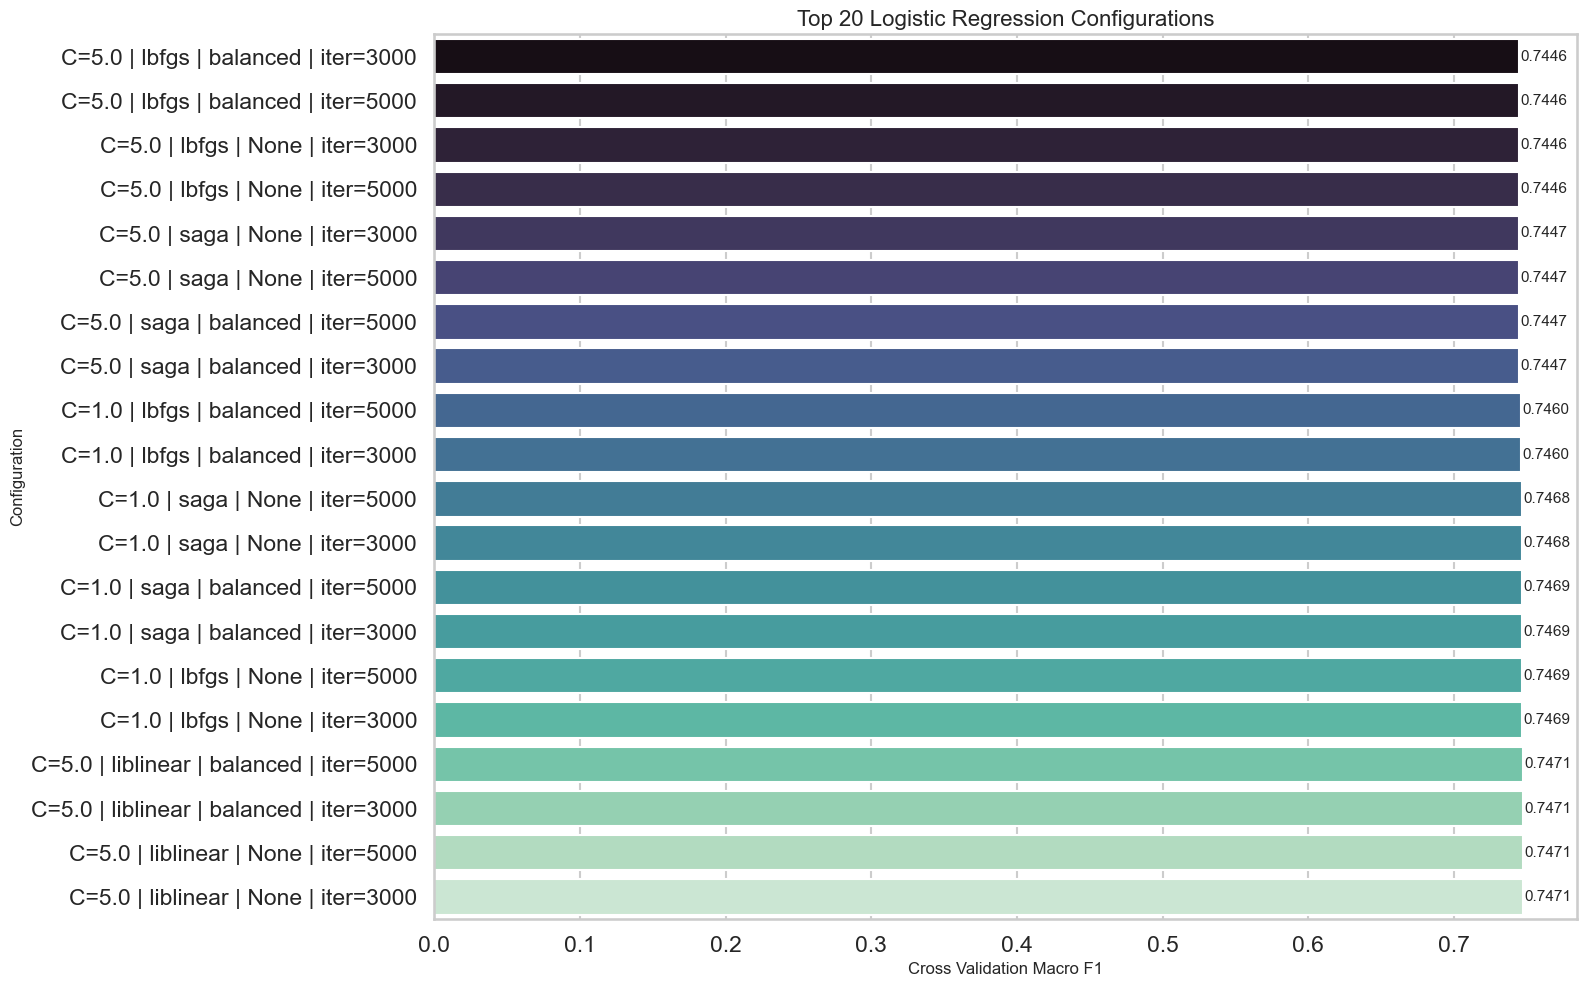


BEST LOGISTIC REGRESSION CONFIGURATION
{'C': 5, 'solver': 'liblinear', 'class_weight': None, 'max_iter': 3000}


In [34]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuning_model = build_pipeline(
    BEST_TFIDF_PARAMS
)

param_grid = {
    "logreg__C": [
        0.01,
        0.1,
        1,
        5,
        10,
        25,
        50,
        100
    ],
    "logreg__solver": [
        "lbfgs",
        "liblinear",
        "saga"
    ],
    "logreg__class_weight": [
        None,
        "balanced"
    ],
    "logreg__max_iter": [
        3000,
        5000
    ]
}

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(
    X_train,
    train_y
)

print("=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

print(grid_search.best_params_)
print(
    "\nBest CV Macro F1:",
    round(grid_search.best_score_, 4)
)

# ============================================================
# GRID RESULTS
# ============================================================

grid_results = pd.DataFrame(
    grid_search.cv_results_
)

cols_to_show = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "param_logreg__C",
    "param_logreg__solver",
    "param_logreg__class_weight",
    "param_logreg__max_iter"
]

grid_results_table = (
    grid_results[cols_to_show]
    .sort_values(
        "rank_test_score"
    )
    .reset_index(
        drop=True
    )
)

display(
    grid_results_table.head(20)
)

# ============================================================
# VISUALIZATION
# ============================================================

top_grid = (
    grid_results_table
    .head(20)
    .copy()
)

top_grid["config"] = (
    "C="
    + top_grid["param_logreg__C"].astype(str)
    + " | "
    + top_grid["param_logreg__solver"].astype(str)
    + " | "
    + top_grid["param_logreg__class_weight"].astype(str)
    + " | iter="
    + top_grid["param_logreg__max_iter"].astype(str)
)

fig, ax = plt.subplots(
    figsize=(16, 10)
)

sns.barplot(
    data=top_grid.sort_values(
        "mean_test_score",
        ascending=True
    ),
    x="mean_test_score",
    y="config",
    palette="mako",
    ax=ax
)

ax.set_title(
    "Top 20 Logistic Regression Configurations"
)

ax.set_xlabel(
    "Cross Validation Macro F1"
)

ax.set_ylabel(
    "Configuration"
)

for i, score in enumerate(
    top_grid.sort_values(
        "mean_test_score",
        ascending=True
    )["mean_test_score"]
):
    ax.text(
        score + 0.001,
        i,
        f"{score:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# ============================================================
# BEST MODEL SUMMARY
# ============================================================

best_params = grid_search.best_params_

BEST_LOGREG_PARAMS = {
    "C": best_params["logreg__C"],
    "solver": best_params["logreg__solver"],
    "class_weight": best_params["logreg__class_weight"],
    "max_iter": best_params["logreg__max_iter"]
}

print("\nBEST LOGISTIC REGRESSION CONFIGURATION")
print(BEST_LOGREG_PARAMS)

## SECTION 8 - Final Model Training

Final model dibangun menggunakan parameter terbaik dari GridSearchCV. Model kemudian dilatih kembali pada training set agar seluruh data latih berkontribusi pada parameter final.

In [35]:
# ============================================================
# FINAL MODEL TRAINING
# ============================================================

X_train_final = pd.concat(
    [
        X_train,
        X_val
    ],
    axis=0
).reset_index(drop=True)

y_train_final = np.concatenate(
    [
        train_y,
        val_y
    ]
)

print("=" * 60)
print("FINAL TRAINING DATA")
print("=" * 60)
print("Train + Validation Samples :", len(X_train_final))
print("Test Samples               :", len(X_test))

# ============================================================
# BUILD FINAL MODEL
# ============================================================

final_model = build_pipeline(
    BEST_TFIDF_PARAMS
)

final_model.set_params(
    **grid_search.best_params_
)

final_model.fit(
    X_train_final,
    y_train_final
)

# ============================================================
# EXTRACT COMPONENTS
# ============================================================

final_vectorizer = final_model.named_steps["tfidf"]
final_classifier = final_model.named_steps["logreg"]

# ============================================================
# MODEL SUMMARY
# ============================================================

print("\nFINAL MODEL FITTED SUCCESSFULLY")

print(
    "\nVocabulary Size:",
    len(final_vectorizer.vocabulary_)
)

print(
    "\nBest Logistic Regression Parameters:"
)

for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")

print(
    "\nNumber of Classes:",
    len(final_classifier.classes_)
)

print(
    "Classes:",
    list(label_encoder.classes_)
)

# ============================================================
# FEATURE SPACE INFO
# ============================================================

feature_names = (
    final_vectorizer
    .get_feature_names_out()
)

print(
    "\nTotal Features:",
    len(feature_names)
)

print(
    "Coefficient Matrix Shape:",
    final_classifier.coef_.shape
)

print(
    "\nExample Features:"
)

print(
    feature_names[:20]
)

FINAL TRAINING DATA
Train + Validation Samples : 45416
Test Samples               : 8024


c:\Users\ASUS ZENBOOK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(



FINAL MODEL FITTED SUCCESSFULLY

Vocabulary Size: 98903

Best Logistic Regression Parameters:
logreg__C: 5
logreg__class_weight: None
logreg__max_iter: 3000
logreg__solver: liblinear

Number of Classes: 3
Classes: [np.str_('Negative'), np.str_('Neutral'), np.str_('Positive')]

Total Features: 98903
Coefficient Matrix Shape: (3, 98903)

Example Features:
['000an' '00pm' '09mei' '0rp' '100gr' '100k' '100k dlu' '100k nikmatin'
 '100rb' '100rb tidak' '100rban' '100ribu' '10d' '10hari' '10harian'
 '10hrian' '10k' '10km' '10m' '10menit']


## SECTION 9 - Evaluation

Evaluasi dilakukan pada validation set dan test set dengan metrik berikut:
- Accuracy
- Precision
- Recall
- F1 Score

Selain metrik agregat, notebook juga menampilkan classification report lengkap untuk masing-masing split.

In [36]:
# ============================================================
# EVALUATION
# ============================================================

def evaluate_model(
    model,
    x,
    y,
    split_name
):

    pred = model.predict(x)
    proba = model.predict_proba(x)

    metrics = {
        "split": split_name,
        "accuracy": accuracy_score(
            y,
            pred
        ),
        "precision_macro": precision_score(
            y,
            pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y,
            pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y,
            pred,
            average="macro",
            zero_division=0
        )
    }

    report_dict = classification_report(
        y,
        pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(report_dict)
        .T
        .reset_index()
        .rename(
            columns={
                "index": "label"
            }
        )
    )

    return (
        metrics,
        pred,
        proba,
        report_df
    )

# ============================================================
# TEST EVALUATION
# ============================================================

test_metrics, test_pred, test_proba, test_report_df = (
    evaluate_model(
        final_model,
        X_test,
        test_y,
        "test"
    )
)

metrics_df = pd.DataFrame(
    [
        test_metrics
    ]
)

display(metrics_df)

display(
    test_report_df
)

print("=" * 60)
print("TEST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        test_y,
        test_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

,split,accuracy,precision_macro,recall_macro,f1_macro
0,test,0.752991,0.750008,0.753104,0.750946


,label,precision,recall,f1-score,support
0,Negative,0.726316,0.695149,0.710391,2680.000000
1,Neutral,0.696158,0.670905,0.683298,2674.000000
2,Positive,0.827550,0.893258,0.859150,2670.000000
3,accuracy,0.752991,0.752991,0.752991,0.752991
4,macro avg,0.750008,0.753104,0.750946,8024.000000
5,weighted avg,0.749952,0.752991,0.750862,8024.000000


TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.7263    0.6951    0.7104      2680
     Neutral     0.6962    0.6709    0.6833      2674
    Positive     0.8276    0.8933    0.8591      2670

    accuracy                         0.7530      8024
   macro avg     0.7500    0.7531    0.7509      8024
weighted avg     0.7500    0.7530    0.7509      8024



## SECTION 10 - Visualization

Visualisasi dibuat untuk membantu interpretasi performa model secara akademik dan presentatif.

Visualisasi yang disediakan:
1. Confusion Matrix Heatmap
2. ROC Curve multiclass
3. Precision Recall Curve
4. Learning Curve
5. Validation Curve
6. Class Distribution Prediction

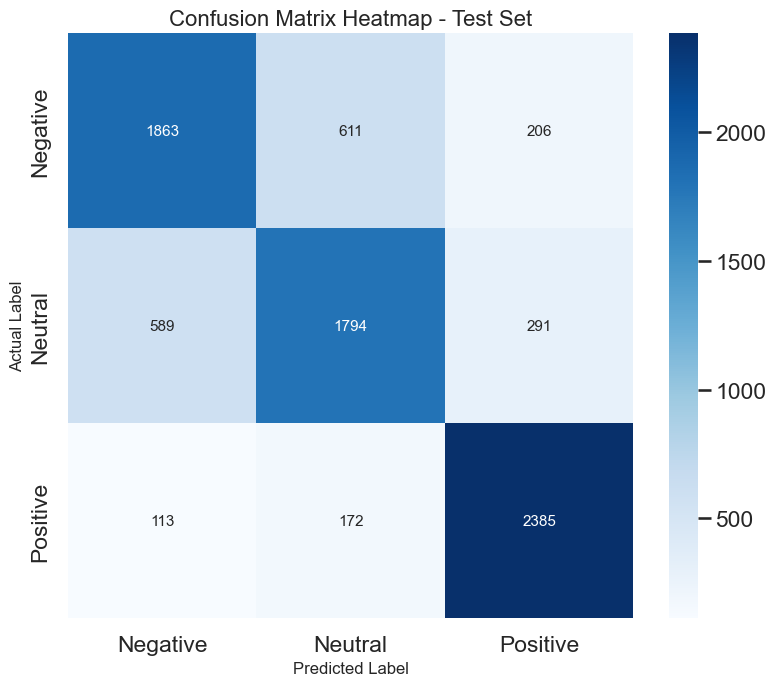

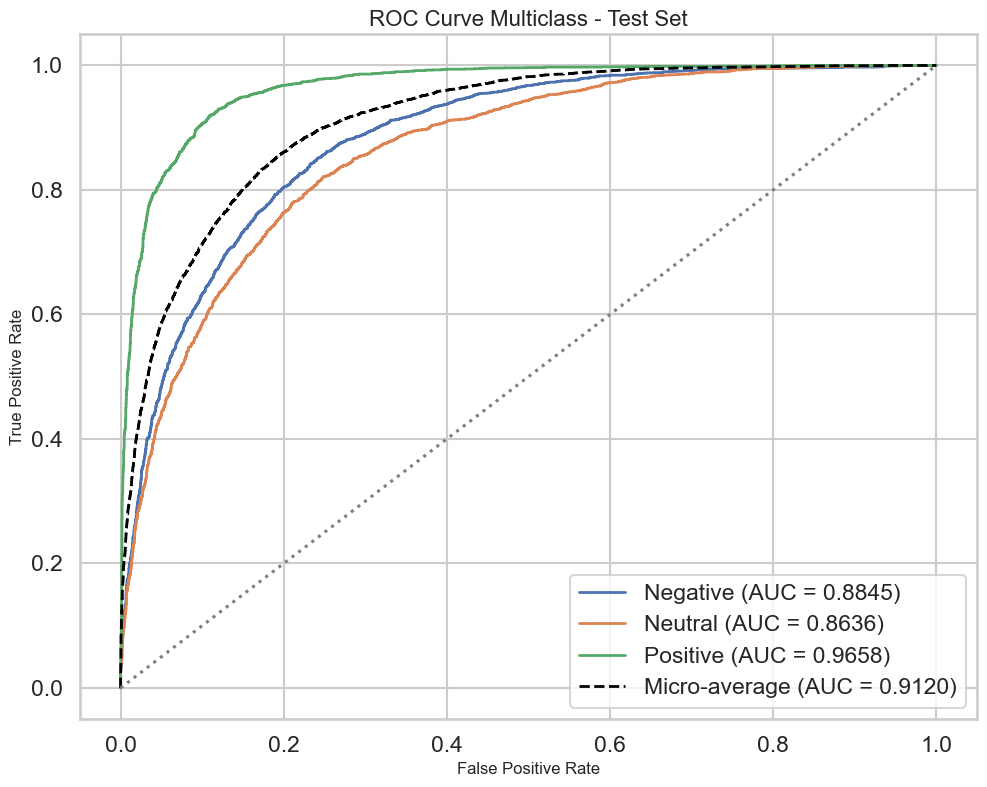

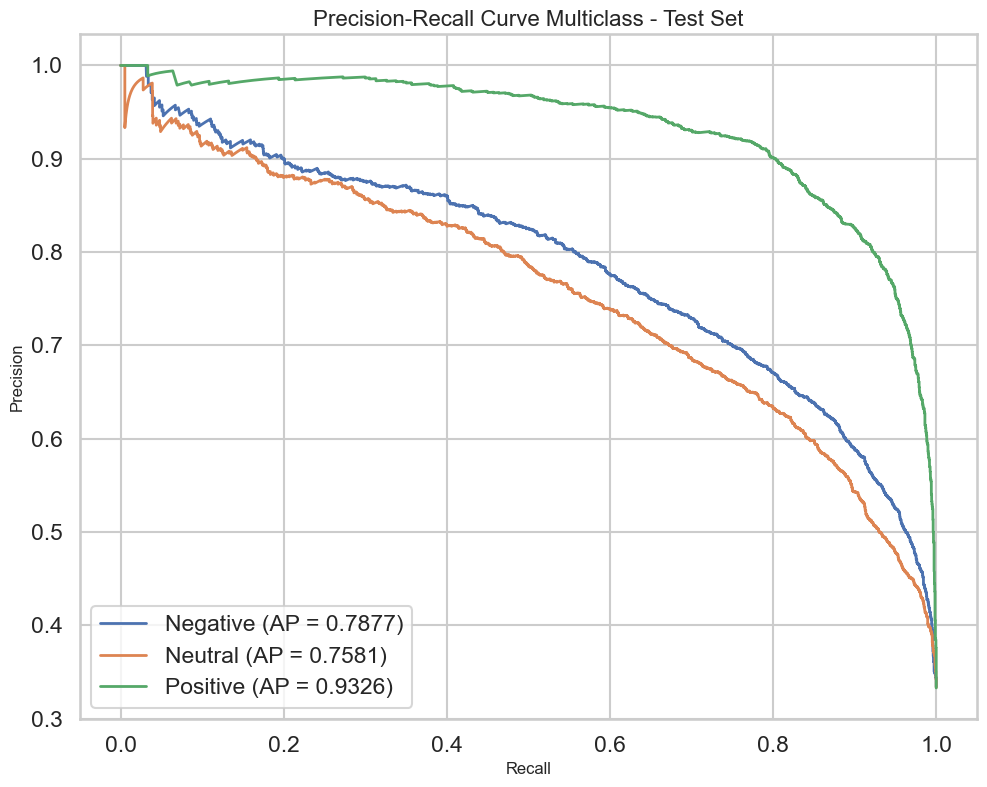

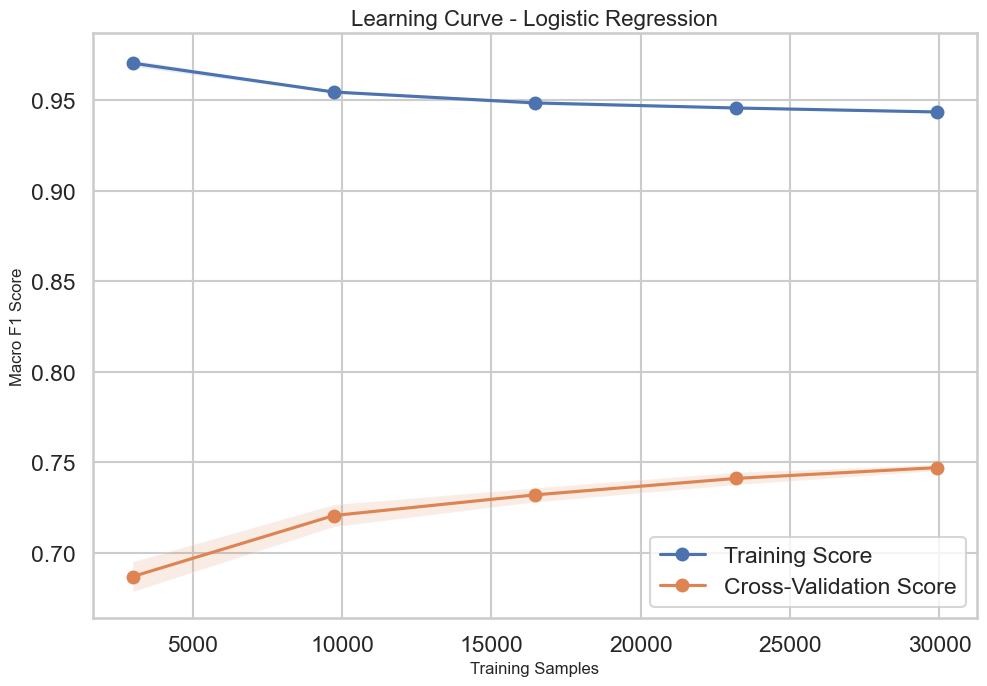

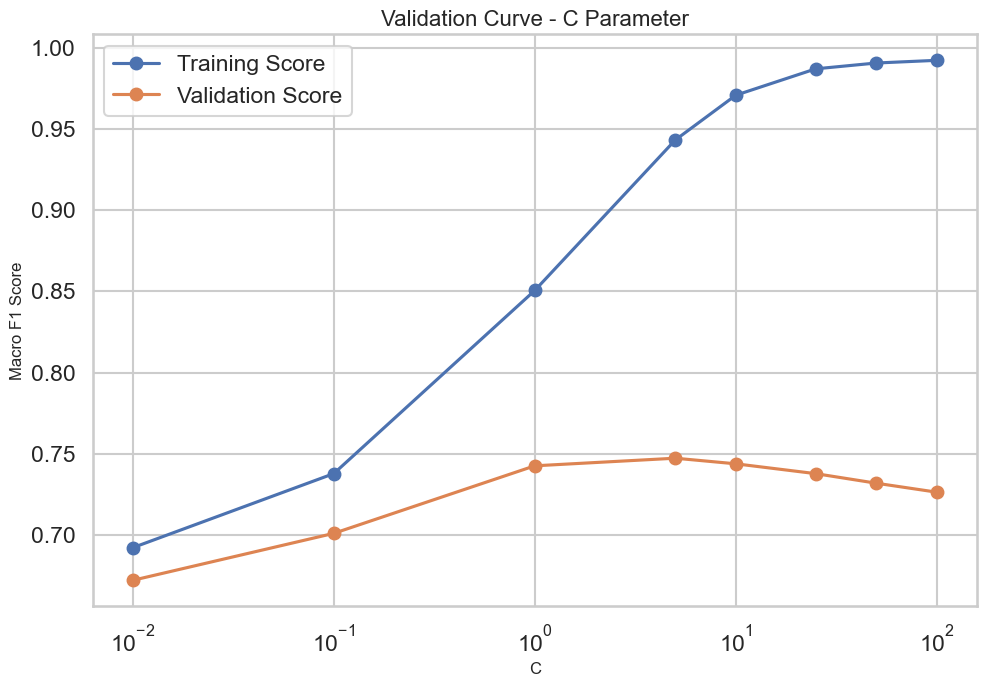

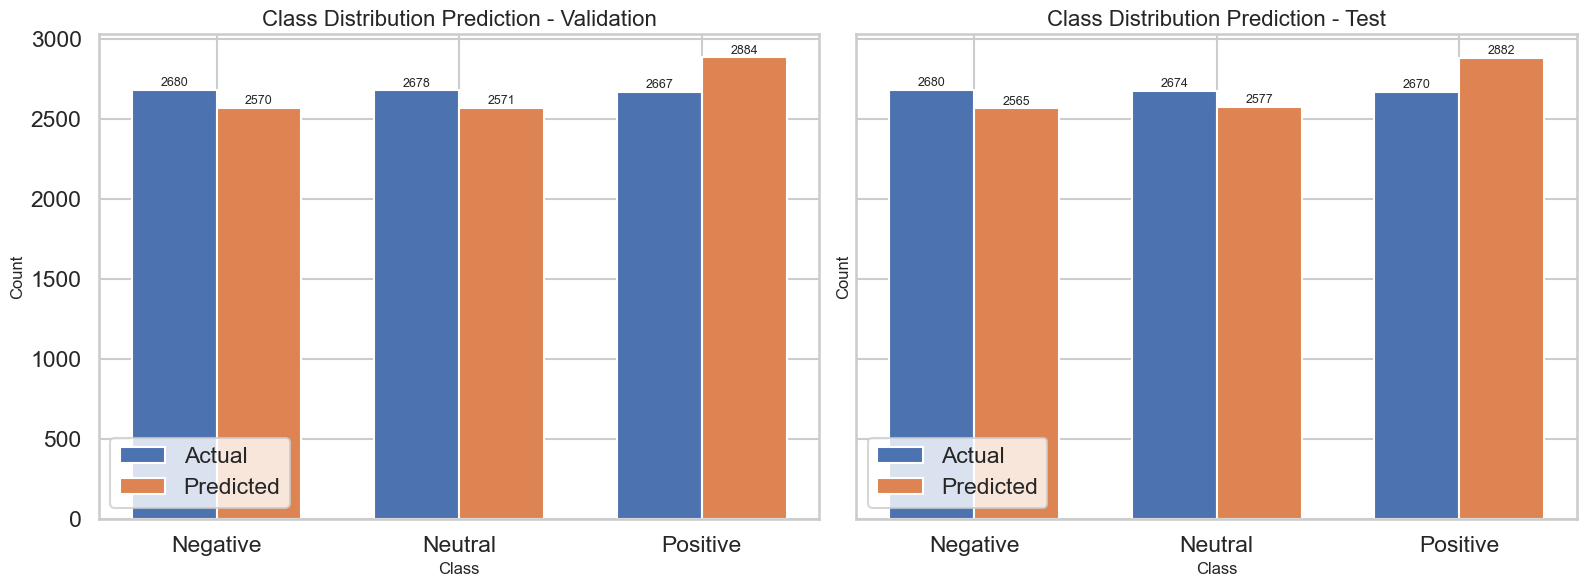

In [37]:
class_names = list(label_encoder.classes_)

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(test_y, test_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix Heatmap - Test Set')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 2. ROC Curve Multiclass
fig, ax = plt.subplots(figsize=(10, 8))
y_test_bin = label_binarize(test_y, classes=list(range(len(class_names))))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.4f})')

fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, linestyle='--', color='black', linewidth=2, label=f'Micro-average (AUC = {roc_auc_micro:.4f})')
ax.plot([0, 1], [0, 1], linestyle=':', color='grey')
ax.set_title('ROC Curve Multiclass - Test Set')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], test_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], test_proba[:, i])
    ax.plot(recall, precision, linewidth=2, label=f'{cls} (AP = {ap:.4f})')
ax.set_title('Precision-Recall Curve Multiclass - Test Set')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 4. Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_model,
    X=X_train,
    y=train_y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42,
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(train_sizes, train_mean, marker='o', label='Training Score')
ax.plot(train_sizes, valid_mean, marker='o', label='Cross-Validation Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15)
ax.set_title('Learning Curve - Logistic Regression')
ax.set_xlabel('Training Samples')
ax.set_ylabel('Macro F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Validation Curve
c_values = np.array([
    0.01,
    0.1,
    1,
    5,
    10,
    25,
    50,
    100
])
val_train_scores, val_test_scores = validation_curve(
    estimator=final_model,
    X=X_train,
    y=train_y,
    param_name='logreg__C',
    param_range=c_values,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(c_values, val_train_scores.mean(axis=1), marker='o', label='Training Score')
ax.plot(c_values, val_test_scores.mean(axis=1), marker='o', label='Validation Score')
ax.set_xscale('log')
ax.set_title('Validation Curve - C Parameter')
ax.set_xlabel('C')
ax.set_ylabel('Macro F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Class Distribution Prediction
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
actual_pred_tables = {
    'Validation': pd.DataFrame({'Actual': pd.Series(val_y).map(inverse_label_mapping).value_counts(), 'Predicted': pd.Series(val_pred).map(inverse_label_mapping).value_counts()}),
    'Test': pd.DataFrame({'Actual': pd.Series(test_y).map(inverse_label_mapping).value_counts(), 'Predicted': pd.Series(test_pred).map(inverse_label_mapping).value_counts()}),
}

for ax, (split_name, table) in zip(axes, actual_pred_tables.items()):
    plot_table = table.reindex(class_names).fillna(0)
    x = np.arange(len(class_names))
    width = 0.35
    ax.bar(x - width / 2, plot_table['Actual'].values, width=width, label='Actual')
    ax.bar(x + width / 2, plot_table['Predicted'].values, width=width, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_title(f'Class Distribution Prediction - {split_name}')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.legend()
    for i, value in enumerate(plot_table['Actual'].values):
        ax.text(i - width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)
    for i, value in enumerate(plot_table['Predicted'].values):
        ax.text(i + width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## SECTION 11 - Error Analysis

Error analysis difokuskan pada contoh yang salah klasifikasi di test set karena test set adalah representasi paling ketat dari generalisasi model.

Tabel berikut menampilkan 50 contoh salah klasifikasi dengan kolom:
- `Review_Text`
- `Actual_Label`
- `Predicted_Label`

In [38]:
test_predictions_df = pd.DataFrame({
    'Review_Text': test_df['Review_Text'],
    'Review_Text_Processed': test_df['Review_Text_Processed'],
    'Actual_Label': pd.Series(test_y).map(inverse_label_mapping),
    'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping),
    'Crisis_Flag': test_df['Crisis_Flag'].values,
    'Is_Sarcasm': test_df['Is_Sarcasm'].values,
    'Business_Category': test_df['Business_Category'].values,
})

misclassified_df = test_predictions_df[test_predictions_df['Actual_Label'] != test_predictions_df['Predicted_Label']].copy()
error_examples = misclassified_df[['Review_Text', 'Actual_Label', 'Predicted_Label']].head(50)

display(error_examples)

print('Jumlah salah klasifikasi:', len(misclassified_df))
print('Error rate:', round(len(misclassified_df) / len(test_predictions_df) * 100, 2), '%')

print('\nPola kesalahan utama:')
print('- Review pendek atau sangat ringkas lebih sulit dibedakan antar kelas.')
print('- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.')
print('- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.')
print('- Review dengan konteks domain tertentu, terutama yang sangat spesifik, dapat diprediksi kurang stabil jika kosakata latih terbatas.')

confusion_pairs = misclassified_df.groupby(['Actual_Label', 'Predicted_Label']).size().sort_values(ascending=False).to_frame('count')
display(confusion_pairs.head(10))

length_summary = misclassified_df['Review_Text_Processed'].fillna('').astype(str).str.split().str.len().describe().to_frame('misclassified_length')
display(length_summary)

,Review_Text,Actual_Label,Predicted_Label
2,"giving a 4 coz i had to take a different cake, not the one which i chose",Positive,Neutral
5,"pesan 4 mie, ada yang pangsitnya 2 ada yang cuma 1. gak jelas banget deh",Neutral,Negative
8,"Td nya sy request utk cancel mo ganti p�byran nya pake gopay dr ovo td nya krn ada cash back, tp nggak dicancel sm toko tetap diproses aja. Sgt m�ngecewakan.",Negative,Neutral
18,kurang bagus..kurang pas sama fotonya,Negative,Positive
21,"rasa ok. tqpi kalo boleh restonya mikirin kebersihan saat order, dengan pake cable tie. lebih siiip.",Positive,Neutral
22,"kemasan kotaknya ada yg penyok dan robek, tp pisaunya aman. padahal mau buat hadiah temen",Neutral,Negative
28,"Pengalaman ikut iklan, pas ada promo biaya iklan per klik 6rupiah...bayar per harinya sampe 60rb berarti 10rb klik..tapi rata2 orderan yang masuk sama aja kayak ga ikut iklan..ikut iklannya seminggu...jadi curiga itu beneran 10rb klik apa gmn..",Neutral,Negative
29,Gimana nih udah tiga hari orderan masuk tapi uang ggak masuk di bank atau pada pencairan dana digobiz,Neutral,Negative
38,"sekarang makin bertingkah driver yang ada disini,begitu pula sistem gojeknya juga lemot dalam mencari driver,terutama saat go food waktu sehabis hujan,hujan sudah lama berhenti tapi lelet banget nyari drivernya,kalo hujan masih deras saya maklumi...",Positive,Negative
42,"Kok ga bisa pesan antar sih sekarang aneh, lagi liburan kah.",Neutral,Negative


Jumlah salah klasifikasi: 1982
Error rate: 24.7 %

Pola kesalahan utama:
- Review pendek atau sangat ringkas lebih sulit dibedakan antar kelas.
- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.
- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.
- Review dengan konteks domain tertentu, terutama yang sangat spesifik, dapat diprediksi kurang stabil jika kosakata latih terbatas.


count
Actual_Label Predicted_Label       
Negative     Neutral            611
Neutral      Negative           589
             Positive           291
Negative     Positive           206
Positive     Neutral            172
             Negative           113

,misclassified_length
count,1982.000000
mean,17.769425
std,22.202837
min,1.000000
25%,6.000000
50%,11.000000
75%,22.000000
max,311.000000


## SECTION 12 - Explainable AI

Koefisien Logistic Regression digunakan untuk mengekstrak kata-kata yang paling berkontribusi pada masing-masing kelas.

Interpretasi yang digunakan di notebook ini adalah:
- kata dengan koefisien tertinggi pada kelas `Positive` dianggap paling mendukung prediksi positif
- kata dengan koefisien tertinggi pada kelas `Negative` dianggap paling mendukung prediksi negatif
- kata dengan koefisien tertinggi pada kelas `Neutral` dianggap paling mendukung prediksi netral

### Top 20 Kata untuk Kelas Positive

,feature,coefficient
0,tidak kecewa,9.517121
1,love,7.838506
2,good,7.423954
3,best,7.420557
4,cepat,6.753340
5,awesome,6.349140
6,excellent,6.136773
7,amazing,6.093913
8,kirim cepat,6.061999
9,recommended,5.698563


### Top 20 Kata untuk Kelas Neutral

,feature,coefficient
0,fore,9.837392
1,kfc,6.416504
2,pizza,5.849821
3,phd,5.757218
4,go resto,5.591397
5,voucher,5.551724
6,super partner,5.350477
7,tolong,5.293151
8,average,5.131582
9,alamat,5.064453


### Top 20 Kata untuk Kelas Negative

,feature,coefficient
0,worst,10.241243
1,buruk,8.162525
2,pathetic,6.827612
3,kecewa,5.950894
4,not good,5.942746
5,rusak,5.833300
6,parah,5.790596
7,not,5.564308
8,potong,5.326764
9,tidak sesuai,5.191504


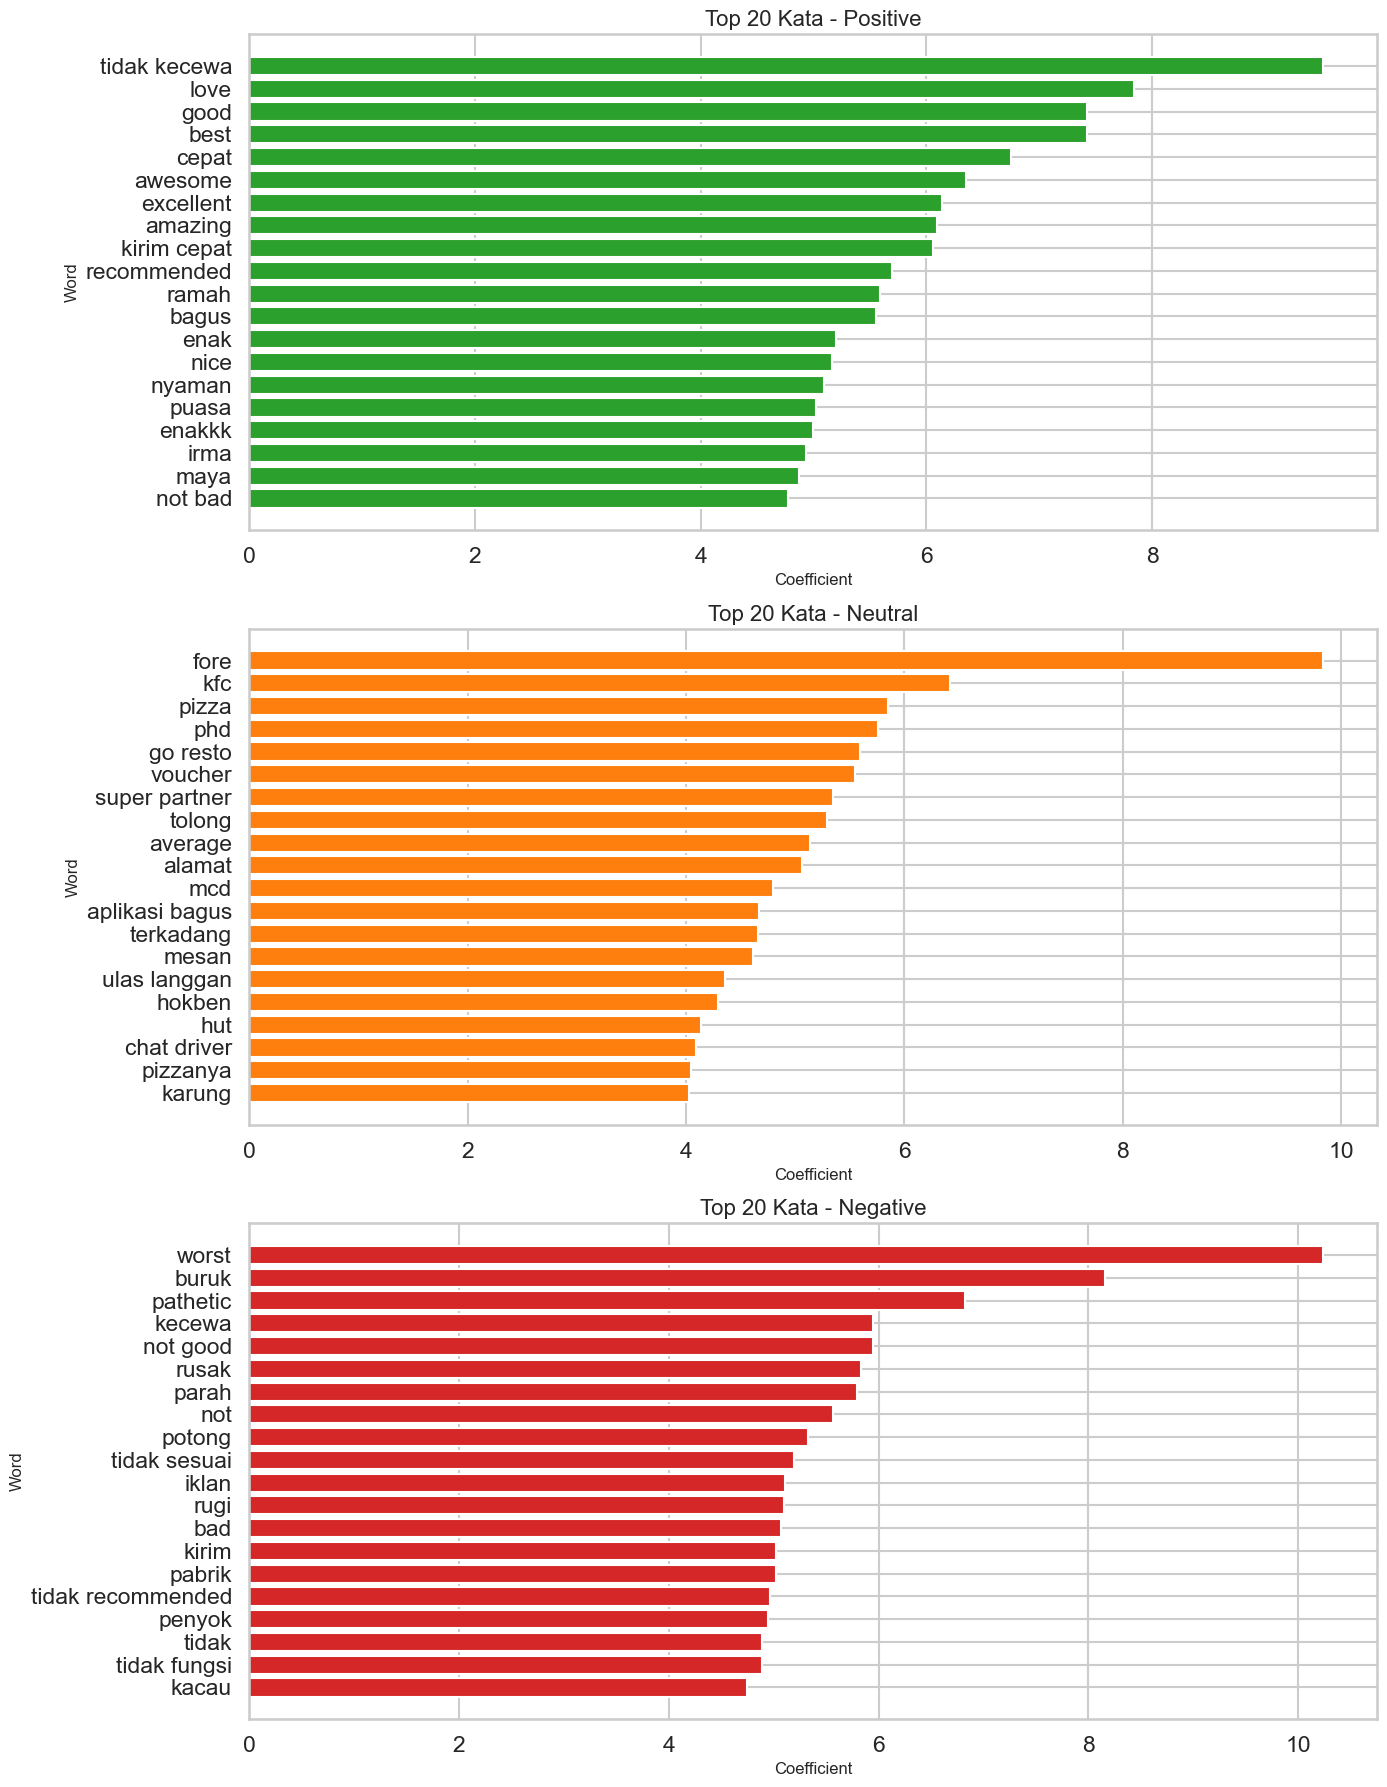

In [39]:
feature_names = np.array(final_vectorizer.get_feature_names_out())
coef = final_classifier.coef_

def resolve_class_index(class_name):
    encoded_value = label_mapping[class_name]
    return np.where(final_classifier.classes_ == encoded_value)[0][0]

explainable_tables = {}
for class_name in ['Positive', 'Neutral', 'Negative']:
    class_idx = resolve_class_index(class_name)
    class_coef = coef[class_idx]
    top_idx = np.argsort(class_coef)[-20:][::-1]
    table = pd.DataFrame({
        'feature': feature_names[top_idx],
        'coefficient': class_coef[top_idx],
    })
    explainable_tables[class_name] = table
    display(Markdown(f'### Top 20 Kata untuk Kelas {class_name}'))
    display(table)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
colors = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
for ax, class_name in zip(axes, ['Positive', 'Neutral', 'Negative']):
    table = explainable_tables[class_name].sort_values('coefficient', ascending=True)
    ax.barh(table['feature'], table['coefficient'], color=colors[class_name])
    ax.set_title(f'Top 20 Kata - {class_name}')
    ax.set_xlabel('Coefficient')
    ax.set_ylabel('Word')
plt.tight_layout()
plt.show()

## SECTION 13 - Business Analysis

Analisis bisnis digunakan untuk melihat apakah model bekerja konsisten pada subset data tertentu.

Subgroup yang dianalisis:
- `Crisis_Flag`
- `Is_Sarcasm`
- `Business_Category`

Tujuannya adalah mengecek apakah ada segmentasi data yang secara sistematis lebih sulit diprediksi.

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro
0,No,7330,0.745975,0.735004,0.737736,0.735669
1,Yes,694,0.827089,0.333333,0.275696,0.301788


,Is_Sarcasm,count,accuracy,precision_macro,recall_macro,f1_macro
0,No,7976,0.754137,0.751029,0.753911,0.751945
1,Yes,48,0.562500,0.333333,0.187500,0.240000


,Business_Category,count,accuracy,precision_macro,recall_macro,f1_macro
10,Perawatan Hewan,20,1.000000,1.000000,1.000000,1.000000
1,F&B,6563,0.746915,0.747865,0.753726,0.750417
9,Perabotan,26,0.730769,0.685185,0.666667,0.643972
8,Otomotif,10,0.900000,0.666667,0.619048,0.641026
3,Hobi & Hiburan,90,0.777778,0.650463,0.637543,0.630470
6,Kesehatan & Kecantikan,50,0.780000,0.634127,0.636420,0.617316
2,Fashion,94,0.755319,0.675161,0.647249,0.612045
5,Kerajinan & Pesta,24,0.833333,0.615385,0.605556,0.609123
4,Ibu & Bayi,21,0.857143,0.600000,0.606061,0.601504
0,Elektronik,110,0.727273,0.631518,0.608907,0.582952


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_3016\701132784.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0], palette='coolwarm')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_3016\701132784.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[1], palette='magma')


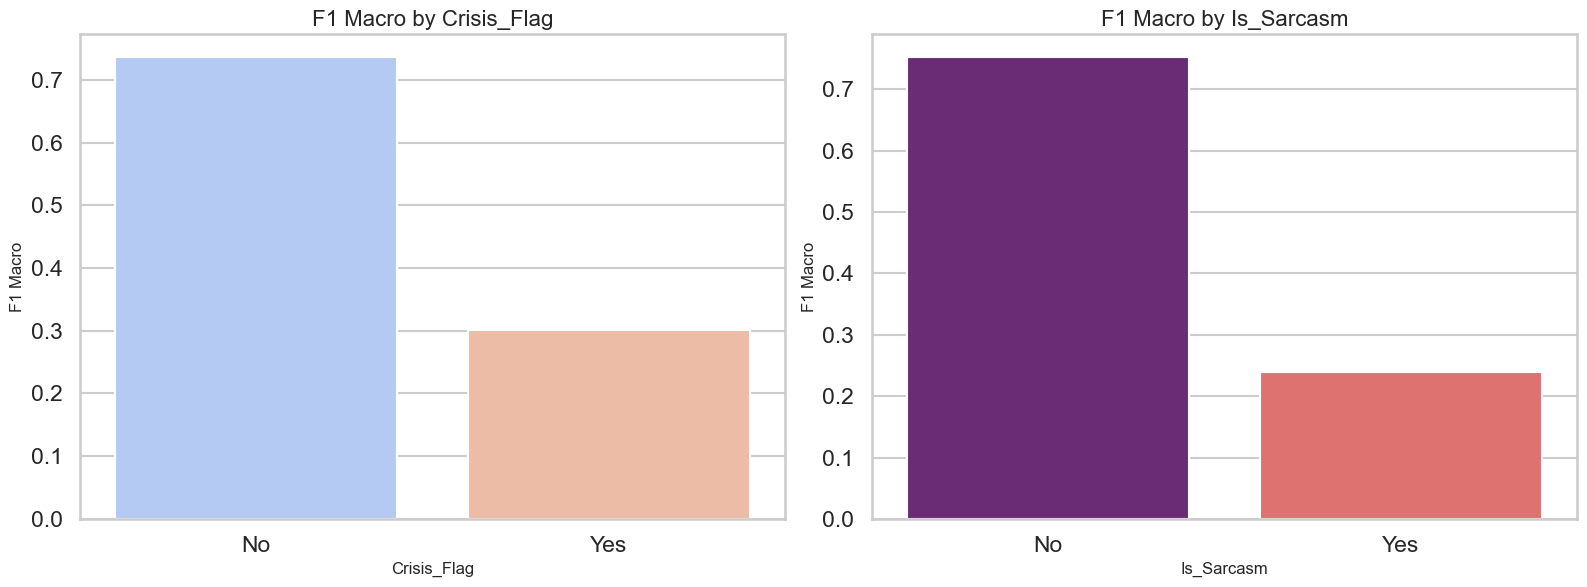

C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_3016\701132784.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=ax, palette='viridis')


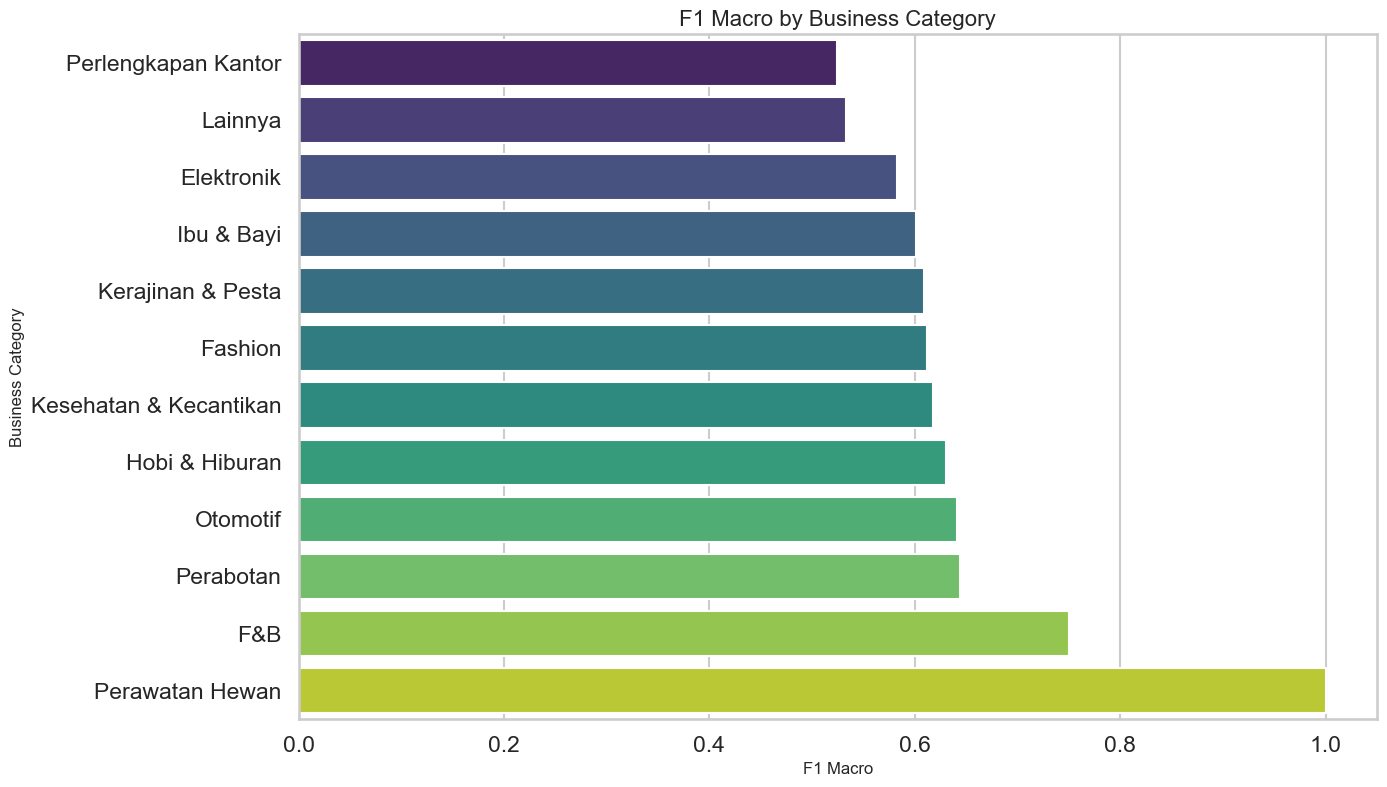

In [40]:
def subgroup_metrics(df_source, actual_array, pred_array, group_col, min_count=1):
    temp = df_source[[group_col]].copy()
    temp['Actual'] = actual_array
    temp['Predicted'] = pred_array
    rows = []
    for group_value, group_df in temp.groupby(group_col):
        if len(group_df) < min_count:
            continue
        rows.append({
            group_col: group_value,
            'count': len(group_df),
            'accuracy': accuracy_score(group_df['Actual'], group_df['Predicted']),
            'precision_macro': precision_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'recall_macro': recall_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'f1_macro': f1_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
        })
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False)

crisis_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Crisis_Flag')
sarcasm_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Is_Sarcasm')
category_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Business_Category', min_count=10)

display(crisis_metrics)
display(sarcasm_metrics)
display(category_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0], palette='coolwarm')
axes[0].set_title('F1 Macro by Crisis_Flag')
axes[0].set_xlabel('Crisis_Flag')
axes[0].set_ylabel('F1 Macro')

sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[1], palette='magma')
axes[1].set_title('F1 Macro by Is_Sarcasm')
axes[1].set_xlabel('Is_Sarcasm')
axes[1].set_ylabel('F1 Macro')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
category_plot = category_metrics.sort_values('f1_macro', ascending=True)
sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=ax, palette='viridis')
ax.set_title('F1 Macro by Business Category')
ax.set_xlabel('F1 Macro')
ax.set_ylabel('Business Category')
plt.tight_layout()
plt.show()

## SECTION 14 - Model Saving

Agar model dapat digunakan kembali tanpa retraining, notebook menyimpan tiga artefak utama:
- TF-IDF Vectorizer
- Label Encoder
- Logistic Regression Model

Seluruh artefak disimpan menggunakan Joblib.

In [41]:
# SAVE & VERIFY MODEL ARTIFACTS

artifacts_dir = Path("artifacts/model1")
artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save Components
joblib.dump(
    final_vectorizer,
    artifacts_dir / "tfidf_vectorizer.joblib"
)

joblib.dump(
    label_encoder,
    artifacts_dir / "label_encoder.joblib"
)

joblib.dump(
    final_classifier,
    artifacts_dir / "logistic_regression_model.joblib"
)

# Save Complete Pipeline
joblib.dump(
    final_model,
    artifacts_dir / "logistic_regression_pipeline.joblib"
)

print("=" * 60)
print("MODEL ARTIFACTS SAVED")
print("=" * 60)

for file in artifacts_dir.glob("*"):
    print(file.name)

# VERIFY SAVED PIPELINE

loaded_pipeline = joblib.load(
    artifacts_dir / "logistic_regression_pipeline.joblib"
)

sample_text = [
    "makanan enak pelayanan cepat dan memuaskan"
]

prediction = loaded_pipeline.predict(sample_text)

predicted_label = label_encoder.inverse_transform(
    prediction
)

print("\nSample Prediction:")
print(predicted_label[0])

print("\nSaved to:")
print(artifacts_dir.resolve())

MODEL ARTIFACTS SAVED
label_encoder.joblib
logistic_regression_model.joblib
logistic_regression_pipeline.joblib
tfidf_vectorizer.joblib

Sample Prediction:
Positive

Saved to:
C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\artifacts\model1


## SECTION 15 - Export Result

Section ini mengekspor hasil eksperimen agar dapat dipakai langsung untuk pelaporan capstone, audit model, dan dokumentasi advisor meeting.

File yang disimpan:
- `metrics_logistic_regression.csv`
- `prediction_logistic_regression.csv`
- `classification_report_logistic_regression.csv`

In [42]:
# ============================================================
# EXPORT RESULTS
# ============================================================

results_dir = Path("results/model1")
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# METRICS EXPORT
# ============================================================

metrics_export = pd.DataFrame([
    {
        "split": "test",
        "accuracy": test_metrics["accuracy"],
        "precision_macro": test_metrics["precision_macro"],
        "recall_macro": test_metrics["recall_macro"],
        "f1_macro": test_metrics["f1_macro"]
    }
])

metrics_export.to_csv(
    results_dir / "metrics_logistic_regression.csv",
    index=False
)

# ============================================================
# BEST PARAMETERS EXPORT
# ============================================================

best_params_export = pd.DataFrame([
    {
        **BEST_TFIDF_PARAMS,
        **grid_search.best_params_
    }
])

best_params_export.to_csv(
    results_dir / "best_parameters.csv",
    index=False
)

# ============================================================
# TEST PREDICTIONS EXPORT
# ============================================================

prediction_export = pd.DataFrame({
    "Review_Text": test_df["Review_Text"].values,
    "Review_Text_Processed": test_df["Review_Text_Processed"].values,
    "Actual_Label": pd.Series(
        test_y
    ).map(
        inverse_label_mapping
    ).values,
    "Predicted_Label": pd.Series(
        test_pred
    ).map(
        inverse_label_mapping
    ).values,
    **{
        f"prob_{cls}": test_proba[:, idx]
        for idx, cls in enumerate(class_names)
    }
})

prediction_export.to_csv(
    results_dir / "prediction_logistic_regression.csv",
    index=False
)

# ============================================================
# CLASSIFICATION REPORT EXPORT
# ============================================================

classification_report_export = (
    test_report_df.copy()
)

classification_report_export.insert(
    0,
    "split",
    "test"
)

classification_report_export.to_csv(
    results_dir /
    "classification_report_logistic_regression.csv",
    index=False
)

# ============================================================
# MISCLASSIFIED EXPORT
# ============================================================

misclassified_export = prediction_export[
    prediction_export["Actual_Label"]
    !=
    prediction_export["Predicted_Label"]
].copy()

misclassified_export.to_csv(
    results_dir /
    "misclassified_logistic_regression.csv",
    index=False
)

# ============================================================
# EXPORT SUMMARY
# ============================================================

print("=" * 60)
print("EXPORT COMPLETED")
print("=" * 60)

print(
    "Results Directory:",
    results_dir.resolve()
)

print("\nSaved Files:")

for file in sorted(results_dir.glob("*")):
    print(f"- {file.name}")

print("\nMetrics")
display(metrics_export)

print("\nBest Parameters")
display(best_params_export)

print("\nPrediction Sample")
display(prediction_export.head())

print("\nClassification Report Sample")
display(classification_report_export.head())

print("\nMisclassified Sample")
display(misclassified_export.head())

EXPORT COMPLETED
Results Directory: C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\results\model1

Saved Files:
- best_parameters.csv
- classification_report_logistic_regression.csv
- metrics_logistic_regression.csv
- misclassified_logistic_regression.csv
- prediction_logistic_regression.csv

Metrics


,split,accuracy,precision_macro,recall_macro,f1_macro
0,test,0.752991,0.750008,0.753104,0.750946



Best Parameters


,analyzer,ngram_range,max_features,min_df,max_df,logreg__C,logreg__class_weight,logreg__max_iter,logreg__solver
0,word,"(1, 2)",100000,2,0.95,5,None,3000,liblinear



Prediction Sample


,Review_Text,Review_Text_Processed,Actual_Label,Predicted_Label,prob_Negative,prob_Neutral,prob_Positive
0,this store maintains the kualitas & brand name of domino's. their burger pizza is great in rasa. its perfect balance of spices & the bland bread rasa. our order was delivered on time and in good condition. overall its a pengalaman baik.,this store maintains the kualitas brand name of domino their burger pizza is great in its perfect balance of spices the bland bread our was delivered on time and in good condition overall its alam,Positive,Positive,0.013078,0.148341,0.838581
1,Orderan nya kurang gacor sengdangkan Kouta ttp harus berlangsung,order gacor sengdangkan kouta ttp,Neutral,Neutral,0.179831,0.540665,0.279504
2,"giving a 4 coz i had to take a different cake, not the one which i chose",giving coz had to take different cake not the one which chose,Positive,Neutral,0.314719,0.669339,0.015942
3,"Parah go gek, masak orderan go food udh di diemin sehari saldo blum masuk ke rekening dan hal ini sudah berulang berapa kali sampai sering komplain ke admin msih lambat masuknya saldo ke rekening, padahal uang dari hasil penjualan mau dipakai bua...",parah go gek masak order go food diemin hari saldo blum rekening ulang komplain admin msih lambat masuk saldo rekening uang hasil jual pakai modal bahan baku masakan resto evaluasi kerja sistem kerja adminya go food terima kasih,Negative,Negative,0.818179,0.179922,0.001899
4,hi . i got cake from here which called some joy cake chocolate. very good and delicioasa. superb rasa..would recommend to anyone will try it again and again ...,hi got cake from here which called some joy cake chocolate very good and delicioasa superb would recommend to anyone will try it again and again,Positive,Positive,0.032552,0.019567,0.947881



Classification Report Sample


,split,label,precision,recall,f1-score,support
0,test,Negative,0.726316,0.695149,0.710391,2680.000000
1,test,Neutral,0.696158,0.670905,0.683298,2674.000000
2,test,Positive,0.827550,0.893258,0.859150,2670.000000
3,test,accuracy,0.752991,0.752991,0.752991,0.752991
4,test,macro avg,0.750008,0.753104,0.750946,8024.000000



Misclassified Sample


,Review_Text,Review_Text_Processed,Actual_Label,Predicted_Label,prob_Negative,prob_Neutral,prob_Positive
2,"giving a 4 coz i had to take a different cake, not the one which i chose",giving coz had to take different cake not the one which chose,Positive,Neutral,0.314719,0.669339,0.015942
5,"pesan 4 mie, ada yang pangsitnya 2 ada yang cuma 1. gak jelas banget deh",mie pangsit tidak banget,Neutral,Negative,0.598785,0.104024,0.297191
8,"Td nya sy request utk cancel mo ganti p�byran nya pake gopay dr ovo td nya krn ada cash back, tp nggak dicancel sm toko tetap diproses aja. Sgt m�ngecewakan.",td sy request cancel mo ganti byran pake gopay dr ovo td cash back tidak dicancel sm toko proses sgt ngecewakan,Negative,Neutral,0.371693,0.545066,0.083241
18,kurang bagus..kurang pas sama fotonya,bagus pas foto,Negative,Positive,0.058177,0.226866,0.714957
21,"rasa ok. tqpi kalo boleh restonya mikirin kebersihan saat order, dengan pake cable tie. lebih siiip.",ok tqpi kalo restonya mikirin bersih pake cable tie siiip,Positive,Neutral,0.112419,0.512144,0.375437


## SECTION 16 - Final Conclusion

Ringkasan otomatis berikut dihasilkan dari metrik validasi dan test. Bagian ini dapat langsung dipakai sebagai bahan narasi laporan capstone atau diskusi advisor meeting.

In [43]:
summary_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Test_F1": [test_metrics["f1_macro"]],
    "TFIDF": [str(BEST_TFIDF_PARAMS)]
})

display(summary_df)

,Model,Test_F1,TFIDF
0,Logistic Regression,0.750946,"{'analyzer': 'word', 'ngram_range': (1, 2), 'max_features': 100000, 'min_df': 2, 'max_df': 0.95}"


In [44]:
final_conclusion_md = f'''
### Final Conclusion

**Test Performance**
- Accuracy: {test_metrics['accuracy']:.4f}
- Precision: {test_metrics['precision_macro']:.4f}
- Recall: {test_metrics['recall_macro']:.4f}
- F1 Score: {test_metrics['f1_macro']:.4f}

**Model Configuration**
- TF-IDF Parameters: {BEST_TFIDF_PARAMS}
- Logistic Regression Parameters: {grid_search.best_params_}

**Kelebihan Model**
- Logistic Regression memberikan baseline yang stabil, cepat, dan mudah diinterpretasikan.
- TF-IDF mampu menangani data teks berdimensi tinggi secara efisien.
- Character N-Gram dan Word N-Gram meningkatkan kemampuan model dalam menangkap variasi kata dan typo.
- Koefisien model dapat digunakan untuk explainability sehingga mendukung analisis akademik dan bisnis.

**Kekurangan Model**
- Model linear masih memiliki keterbatasan dalam memahami konteks yang kompleks.
- Sarkasme, negasi panjang, dan kalimat ambigu masih dapat menyebabkan salah klasifikasi.
- Performa sangat bergantung pada kualitas preprocessing dan representasi fitur TF-IDF.
- Model belum memanfaatkan informasi kontekstual mendalam seperti yang tersedia pada model transformer.

**Kesimpulan**
- Logistic Regression berhasil membangun baseline klasifikasi sentimen yang kuat dan dapat direproduksi.
- Model ini layak digunakan sebagai benchmark untuk perbandingan dengan SVM dan IndoBERT pada eksperimen berikutnya.
'''

display(Markdown(final_conclusion_md))


### Final Conclusion

**Test Performance**
- Accuracy: 0.7530
- Precision: 0.7500
- Recall: 0.7531
- F1 Score: 0.7509

**Model Configuration**
- TF-IDF Parameters: {'analyzer': 'word', 'ngram_range': (1, 2), 'max_features': 100000, 'min_df': 2, 'max_df': 0.95}
- Logistic Regression Parameters: {'logreg__C': 5, 'logreg__class_weight': None, 'logreg__max_iter': 3000, 'logreg__solver': 'liblinear'}

**Kelebihan Model**
- Logistic Regression memberikan baseline yang stabil, cepat, dan mudah diinterpretasikan.
- TF-IDF mampu menangani data teks berdimensi tinggi secara efisien.
- Character N-Gram dan Word N-Gram meningkatkan kemampuan model dalam menangkap variasi kata dan typo.
- Koefisien model dapat digunakan untuk explainability sehingga mendukung analisis akademik dan bisnis.

**Kekurangan Model**
- Model linear masih memiliki keterbatasan dalam memahami konteks yang kompleks.
- Sarkasme, negasi panjang, dan kalimat ambigu masih dapat menyebabkan salah klasifikasi.
- Performa sangat bergantung pada kualitas preprocessing dan representasi fitur TF-IDF.
- Model belum memanfaatkan informasi kontekstual mendalam seperti yang tersedia pada model transformer.

**Kesimpulan**
- Logistic Regression berhasil membangun baseline klasifikasi sentimen yang kuat dan dapat direproduksi.
- Model ini layak digunakan sebagai benchmark untuk perbandingan dengan SVM dan IndoBERT pada eksperimen berikutnya.
